# Tyre Degradation Analysis
Modelling how lap times evolve over a stint using F1 lap time data.
Dataset: Ergast F1 CSV (Rohan Rao / Kaggle)

Loaded and explored real F1 lap time data
Identified and isolated pit stop laps
Detected a VSC period by cross referencing all drivers
Cleaned a stint by removing non-representative laps
Fitted a linear degradation model
Compared linear vs quadratic fit
Visualized everything with dark themed charts

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use('dark_background')

laps = pd.read_csv("data/lap_times.csv", na_values="\\N")
print(laps.shape)
print(laps.head())

(589081, 6)
   raceId  driverId  lap  position      time  milliseconds
0     841        20    1         1  1:38.109         98109
1     841        20    2         1  1:33.006         93006
2     841        20    3         1  1:32.713         92713
3     841        20    4         1  1:32.803         92803
4     841        20    5         1  1:32.342         92342


In [102]:
races = pd.read_csv("data/races.csv", na_values="\\N")
print(races.tail(20))

      raceId  year  round  circuitId                       name        date  \
1105    1125  2024      5         17         Chinese Grand Prix  2024-04-21   
1106    1126  2024      6         79           Miami Grand Prix  2024-05-05   
1107    1127  2024      7         21  Emilia Romagna Grand Prix  2024-05-19   
1108    1128  2024      8          6          Monaco Grand Prix  2024-05-26   
1109    1129  2024      9          7        Canadian Grand Prix  2024-06-09   
1110    1130  2024     10          4         Spanish Grand Prix  2024-06-23   
1111    1131  2024     11         70        Austrian Grand Prix  2024-06-30   
1112    1132  2024     12          9         British Grand Prix  2024-07-07   
1113    1133  2024     13         11       Hungarian Grand Prix  2024-07-21   
1114    1134  2024     14         13         Belgian Grand Prix  2024-07-28   
1115    1135  2024     15         39           Dutch Grand Prix  2024-08-25   
1116    1136  2024     16         14         Italian

In [103]:
british_gp = laps[laps['raceId'] == 1132].copy()

print(british_gp.shape)
print(british_gp['driverId'].unique())

(960, 6)
[847   1 830 846 857 832 840 844 807   4 852 848 858 855 817 839 825 822
 815]


In [104]:
british_gp['seconds'] = british_gp['milliseconds'] / 1000

verstappen = british_gp[british_gp['driverId'] == 830].copy()

print(verstappen[['lap', 'seconds']].head(25))

        lap  seconds
575114    1   96.711
575115    2   91.773
575116    3   92.200
575117    4   91.933
575118    5   91.778
575119    6   91.711
575120    7   91.935
575121    8   92.038
575122    9   91.883
575123   10   91.661
575124   11   91.810
575125   12   91.894
575126   13   91.759
575127   14   91.700
575128   15   92.249
575129   16   92.504
575130   17   95.359
575131   18   96.172
575132   19  102.485
575133   20   97.108
575134   21   93.488
575135   22   91.904
575136   23   92.143
575137   24   93.020
575138   25   96.063


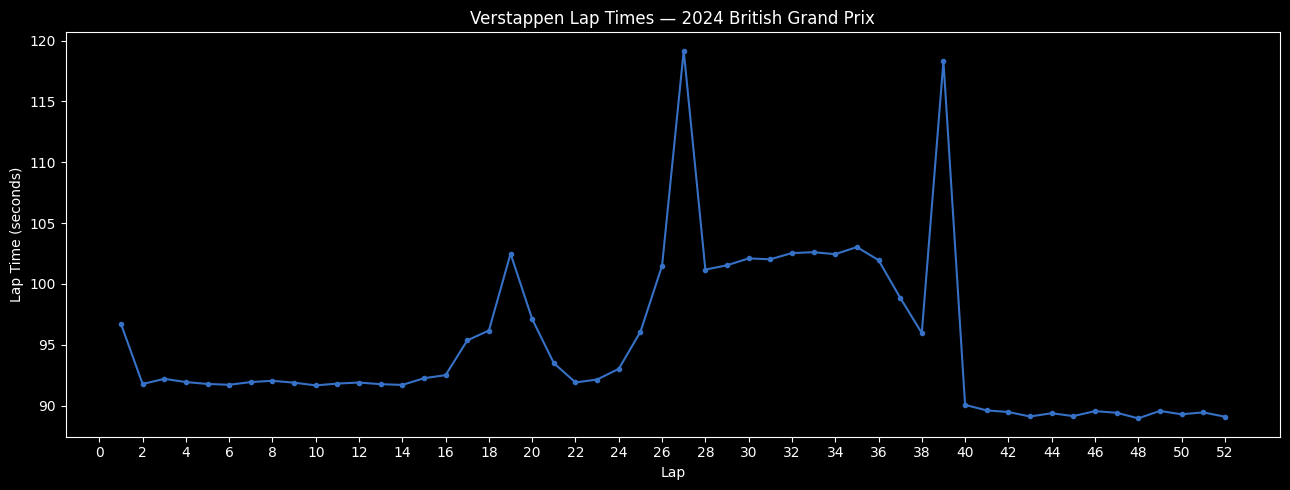

In [105]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(verstappen['lap'], verstappen['seconds'], color='#3671C6', linewidth=1.5, marker='o', markersize=3)

ax.set_xticks(range(0, len(verstappen) + 1, 2))

ax.set_xlabel("Lap")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Verstappen Lap Times — 2024 British Grand Prix")

plt.tight_layout()
plt.show()

In [106]:
pit_stops = pd.read_csv("data/pit_stops.csv", na_values="\\N")

verstappen_pits = pit_stops[
    (pit_stops['raceId'] == 1132) & 
    (pit_stops['driverId'] == 830)
].copy()

print(verstappen_pits[['lap', 'duration', 'milliseconds']])

       lap duration  milliseconds
10951   26   28.365         28365
10974   38   29.076         29076


In [107]:
print(verstappen[verstappen['lap'].isin([25, 26, 27, 37, 38, 39, 40])][['lap', 'seconds']])

        lap  seconds
575138   25   96.063
575139   26  101.491
575140   27  119.169
575150   37   98.869
575151   38   95.963
575152   39  118.311
575153   40   90.056


In [108]:
stint1 = verstappen[(verstappen['lap'] >= 2) & (verstappen['lap'] <= 26)].copy()
stint2 = verstappen[(verstappen['lap'] >= 28) & (verstappen['lap'] <= 38)].copy()
stint3 = verstappen[(verstappen['lap'] >= 40)].copy()

stint1['tyre_age'] = range(1, len(stint1) + 1)
stint2['tyre_age'] = range(1, len(stint2) + 1)
stint3['tyre_age'] = range(1, len(stint3) + 1)

print(f"Stint 1: {len(stint1)} laps")
print(f"Stint 2: {len(stint2)} laps")
print(f"Stint 3: {len(stint3)} laps")

Stint 1: 25 laps
Stint 2: 11 laps
Stint 3: 13 laps


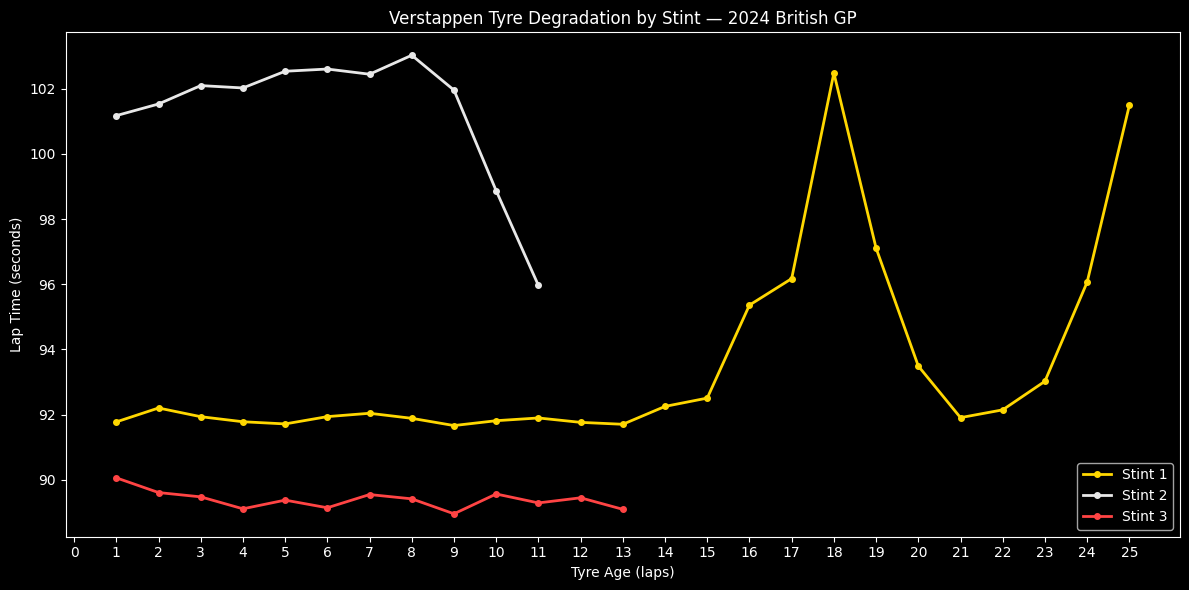

In [109]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(stint1['tyre_age'], stint1['seconds'], color='#FFD700', linewidth=2, marker='o', markersize=4, label='Stint 1')
ax.plot(stint2['tyre_age'], stint2['seconds'], color='#E8E8E8', linewidth=2, marker='o', markersize=4, label='Stint 2')
ax.plot(stint3['tyre_age'], stint3['seconds'], color='#FF4444', linewidth=2, marker='o', markersize=4, label='Stint 3')

ax.set_xticks(range(0, 26, 1))
ax.set_xlabel("Tyre Age (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Verstappen Tyre Degradation by Stint — 2024 British GP")
ax.legend()

plt.tight_layout()
plt.show()

In [110]:
suspicious = stint1[stint1['seconds'] > 94]
print(suspicious[['lap', 'seconds']])

        lap  seconds
575130   17   95.359
575131   18   96.172
575132   19  102.485
575133   20   97.108
575138   25   96.063
575139   26  101.491


In [116]:
all_lap17_20 = british_gp[(british_gp['lap'] >= 17) & (british_gp['lap'] <= 20)][['driverId', 'lap', 'milliseconds']].copy()

pivot = all_lap17_20.pivot(index='lap', columns='driverId', values='milliseconds')
print(pivot)

driverId     1       4       807     815     817     822     825     830  \
lap                                                                        
17         93721   95014   95447   94829   95885   95498   94661   95359   
18         95071   95880   95834   95384   96827   96075   94730   96172   
19        103711  107270  105752  101868  104922  104426  103505  102485   
20        100021   96480   97529  119150   97330   98542   95181   97108   

driverId     832     839     840     844     846     847     848     852  \
lap                                                                        
17         94228   98735   95713   95280   94304   94793   94873   94738   
18         94310   98497   95789   95951   94125   96365   95323   95392   
19        100510  101731  107568  105868  101436  104151  104619  104585   
20         96538  121025   97491  120269   97704   99962   96530   96875   

driverId     855     857     858  
lap                               
17         98106

In [117]:
lap_medians = british_gp.groupby('lap')['milliseconds'].median()

overall_median = lap_medians.median()

vsc_laps = lap_medians[lap_medians > overall_median * 1.08].index.tolist()
print("Suspected VSC/SC laps:", vsc_laps)

Suspected VSC/SC laps: [1, 19, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]


In [118]:
exclude_laps = [1, 19, 25, 26, 27]

stint1_clean = stint1[~stint1['lap'].isin(exclude_laps)].copy()
stint1_clean['tyre_age'] = range(1, len(stint1_clean) + 1)

print(f"Stint 1 clean: {len(stint1_clean)} laps")
print(stint1_clean[['lap', 'tyre_age', 'seconds']])

Stint 1 clean: 22 laps
        lap  tyre_age  seconds
575115    2         1   91.773
575116    3         2   92.200
575117    4         3   91.933
575118    5         4   91.778
575119    6         5   91.711
575120    7         6   91.935
575121    8         7   92.038
575122    9         8   91.883
575123   10         9   91.661
575124   11        10   91.810
575125   12        11   91.894
575126   13        12   91.759
575127   14        13   91.700
575128   15        14   92.249
575129   16        15   92.504
575130   17        16   95.359
575131   18        17   96.172
575133   20        18   97.108
575134   21        19   93.488
575135   22        20   91.904
575136   23        21   92.143
575137   24        22   93.020


In [119]:
import numpy as np

x = stint1_clean['tyre_age']
y = stint1_clean['seconds']

coeffs = np.polyfit(x, y, 1)
slope = coeffs[0]
intercept = coeffs[1]

print(f"Degradation rate: {slope:.3f} seconds per lap")
print(f"Base pace: {intercept:.3f} seconds")

Degradation rate: 0.115 seconds per lap
Base pace: 91.314 seconds


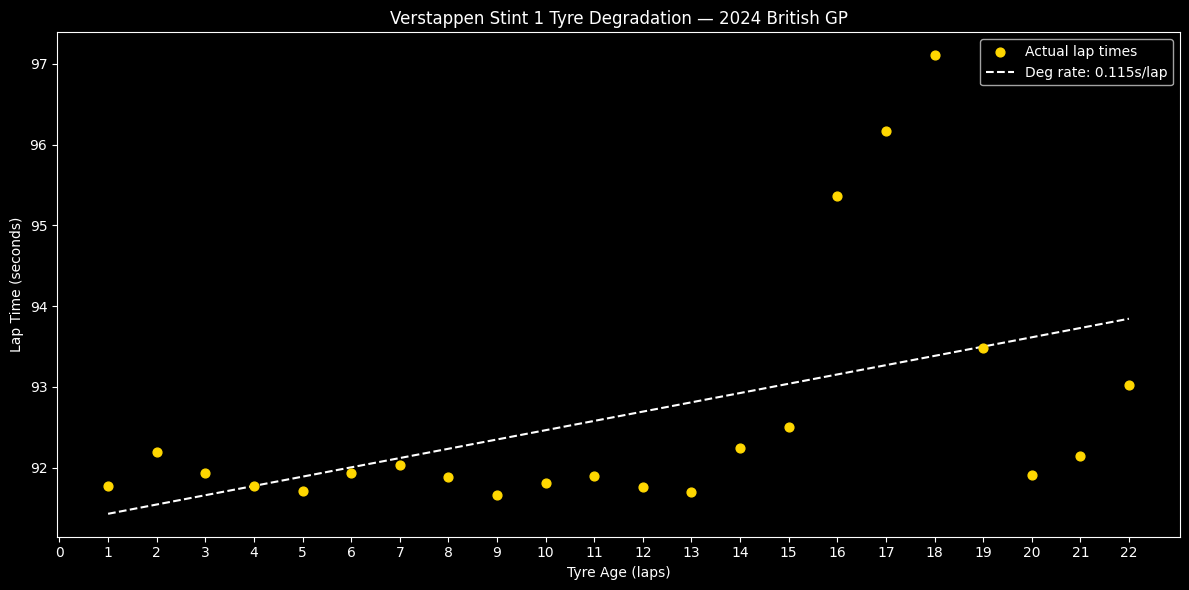

In [120]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint1_clean['tyre_age'], stint1_clean['seconds'], color='#FFD700', s=40, zorder=5, label='Actual lap times')

x_line = np.linspace(1, 22, 100)
y_line = coeffs[0] * x_line + coeffs[1]

ax.plot(x_line, y_line, color='white', linewidth=1.5, linestyle='--', label=f'Deg rate: {slope:.3f}s/lap')

ax.set_xticks(range(0, 23, 1))
ax.set_xlabel("Tyre Age (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Verstappen Stint 1 Tyre Degradation — 2024 British GP")
ax.legend()

plt.tight_layout()
plt.show()

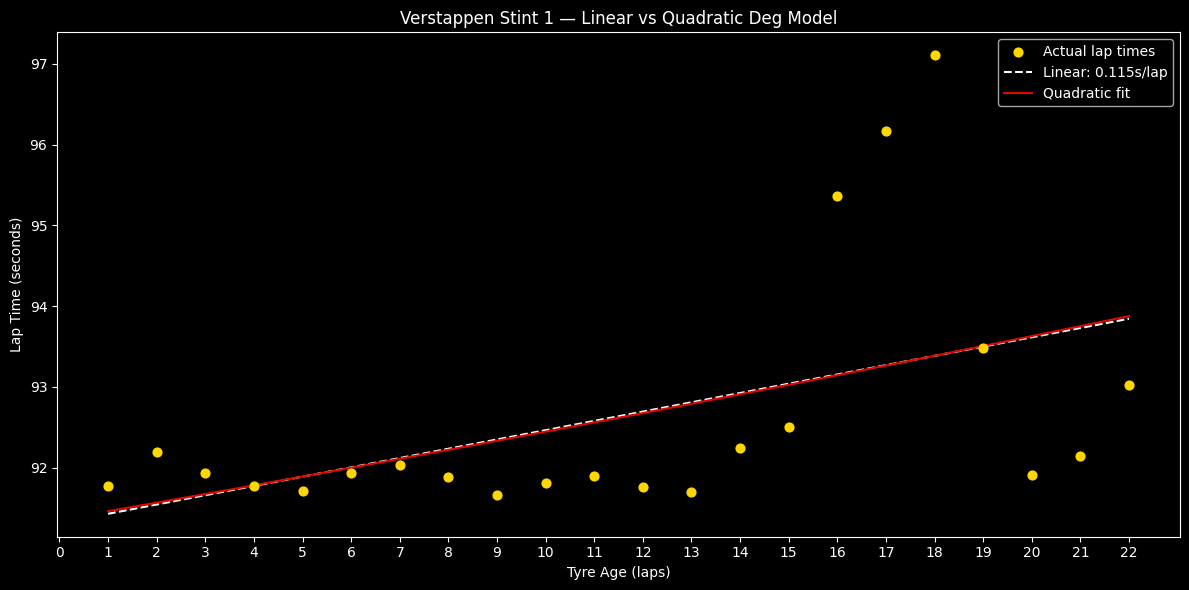

In [122]:
coeffs2 = np.polyfit(x, y, 2)

y_curve = np.polyval(coeffs2, x_line)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(stint1_clean['tyre_age'], stint1_clean['seconds'], color='#FFD700', s=40, zorder=5, label='Actual lap times')

ax.plot(x_line, y_line, color='white', linewidth=1.5, linestyle='--', label=f'Linear: {slope:.3f}s/lap')

ax.plot(x_line, y_curve, color='#E10600', linewidth=1.5, linestyle='-', label='Quadratic fit')

ax.set_xticks(range(0, 23, 1))
ax.set_xlabel("Tyre Age (laps)")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title("Verstappen Stint 1 — Linear vs Quadratic Deg Model")
ax.legend()

plt.tight_layout()
plt.show()